In [1]:
import numpy as np 
import pandas as pd
import os
from readData import *
from mgefit.mge_fit_1d import mge_fit_1d

import matplotlib.pyplot as plt

# Example Galaxy

In [4]:
galaxy = "NGC6503"

In [5]:
df, units, dist = get_rc_data(galaxy)
data, meta_units = get_mass_data(galaxy)

# MGE Fitting

Phase 1-2: SPARC surface brightness  ->  1D MGE of the disk light.
 
We fit the LIGHT (SBdisk, i.e. M/L = 1). The stellar M/L (Upsilon) is a free
MCMC parameter applied downstream as a multiplier on the Gaussian masses, so the
MGE is computed once per galaxy and never re-fit as Upsilon varies.
 
mge_fit_1d convention (verified empirically):

    p.sol[0, k] = INTEGRAL (area) of Gaussian k
    p.sol[1, k] = dispersion sigma_k   [same units as input R, i.e. kpc]
    => peak surface density  Sigma0_k = sol[0,k] / (sqrt(2*pi) * sigma_k)

In [14]:
def fit_disk_mge(R, SBdisk, ngauss=8, plot=True, name=""):
    """
    Parameters
    ----------
    R       : radii [kpc]                (from rotmod file)
    SBdisk  : disk surface brightness [Lsun/pc^2] at M/L=1  (from rotmod file)
    ngauss  : number of Gaussians
 
    Returns
    -------
    dict with:
        sigma_k  : Gaussian dispersions   [kpc]
        Sigma0_k : peak surface densities [Lsun/pc^2]  (multiply by Upsilon later)
        (mass per Gaussian at Upsilon=1, in Lsun, is  2*pi*sigma_k^2 * Sigma0_k * 1e6,
         the 1e6 converting kpc^2 -> pc^2; defer that to the potential step)
    """
    R = np.asarray(R, float)
    SB = np.asarray(SBdisk, float)
 
    # mask non-positive / non-finite SB
    m = np.isfinite(SB) & (SB > 0) & np.isfinite(R) & (R > 0)
    R, SB = R[m], SB[m]
    if R.size < ngauss + 2:
        ngauss = max(3, R.size - 2)
 
    p = mge_fit_1d(R, SB, ngauss=ngauss, plot=False, quiet=True)
    area, sigma = p.sol[0], p.sol[1]
    Sigma0 = area / (np.sqrt(2*np.pi) * sigma)          # peak surface density
 
    # ---- Checkpoint 1: reconstruct and compare ----
    def model(r):
        r = np.atleast_1d(r)[:, None]
        return (Sigma0[None, :] * np.exp(-0.5*(r/sigma[None, :])**2)).sum(1)
 
    recon = model(R)
    relerr = np.abs(recon - SB) / SB
    print(f"[{name}]  ngauss={sigma.size}  "
          f"median rel err={np.median(relerr):.2e}  max={relerr.max():.2e}")
 
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        rr = np.linspace(R.min(), R.max(), 400)
        ax[0].plot(R, SB, 'o', ms=4, label='SBdisk (data)')
        ax[0].plot(rr, model(rr), '-', label='MGE sum')
        for s0, sg in zip(Sigma0, sigma):
            ax[0].plot(rr, s0*np.exp(-0.5*(rr/sg)**2), '--', lw=0.7, alpha=0.6)
        ax[0].set_yscale('log'); ax[0].set_xlabel('R [kpc]')
        ax[0].set_ylabel(r'$\Sigma$ [$L_\odot/pc^2$, $\Upsilon=1$]')
        ax[0].legend(fontsize=8); ax[0].set_title(f'{name}: MGE fit')
        ax[1].plot(R, 100*relerr, 'o-', ms=4)
        ax[1].set_xlabel('R [kpc]'); ax[1].set_ylabel('residual [%]')
        ax[1].axhline(0, color='k', lw=0.5); ax[1].set_title('Checkpoint 1')
        plt.tight_layout(); plt.show()
 
    return dict(sigma_k=sigma, Sigma0_k=Sigma0, name=name)

Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
[NGC6503]  ngauss=5  median rel err=5.93e-02  max=2.47e-01


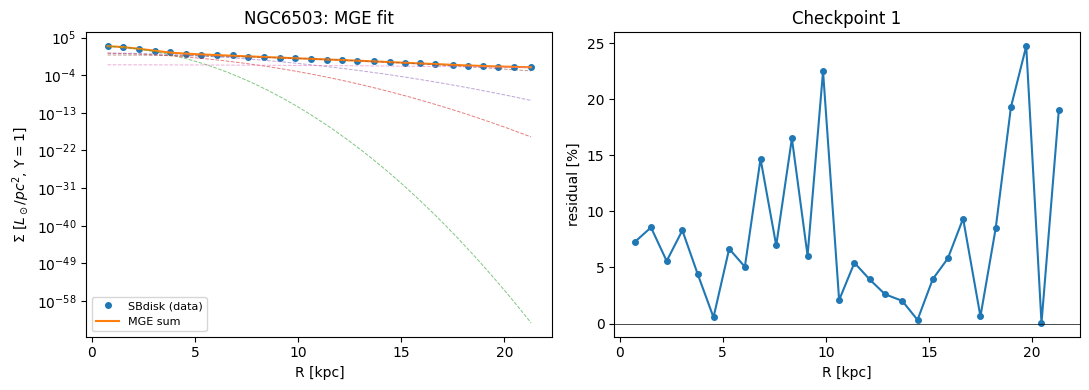

In [16]:
out = fit_disk_mge(df["Rad"].values, df["SBdisk"].values, ngauss=8, name="NGC6503")